<a href="https://colab.research.google.com/github/ag22042008/data-Science-notebooks/blob/main/eda_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [258]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [259]:
df=pd.read_csv('/content/train.csv')


In [260]:
df.head()#sibsp-brother sister with passenger or husband wife of passenger
#parch-parents or children travelling with passenger
#embarked -which station u board s c q

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Bivariate Analysis: Age and Survived

In [261]:
# univariate on age

Age is almost normally distributed
20% values missing
some outliers present

In [262]:
df['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


<Axes: ylabel='Density'>

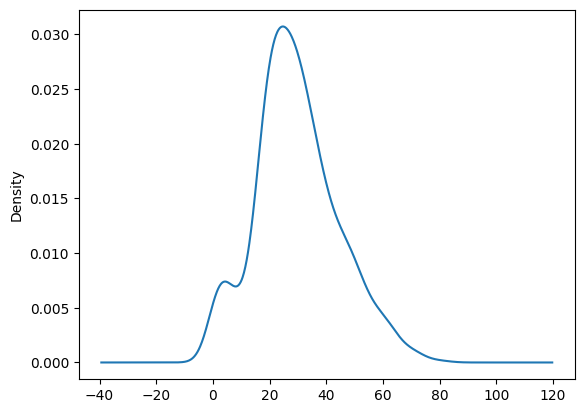

In [263]:
df['Age'].plot(kind='kde')

<Axes: xlabel='Age', ylabel='Count'>

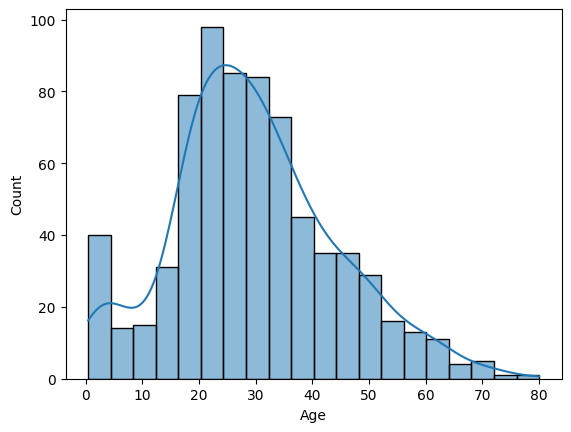

In [264]:
sns.histplot(df['Age'], kde=True,bins=20)

In [265]:
df['Age'].skew()

np.float64(0.38910778230082704)

<Axes: ylabel='Age'>

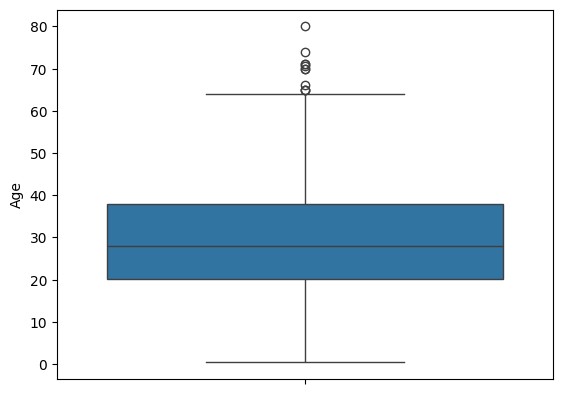

In [266]:
sns.boxplot(df['Age'])

In [267]:
import plotly.express as px

fig = px.box(df, y='Age')
fig.show()

In [268]:
#to check outliers validation
df[df['Age']>65]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [269]:
df['Age'].isnull().sum()/len(df['Age'])

np.float64(0.19865319865319866)

#fare column analysis
std devatiion is high
the data is highly postively skewed
fare column actually contains group fare not actual fare
we need to create a new column called individual fare



In [270]:
df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


<Axes: xlabel='Fare', ylabel='Count'>

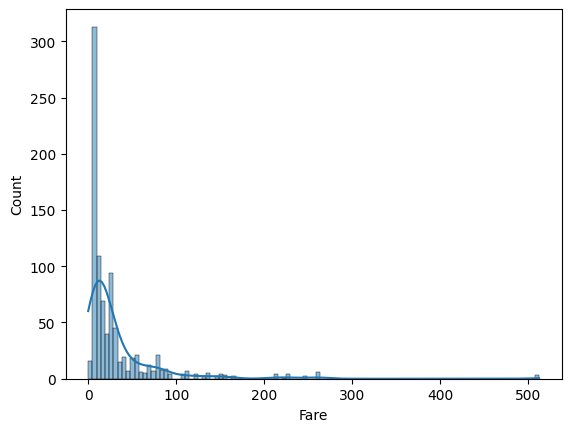

In [271]:
sns.histplot(df['Fare'],kde=True)

<Axes: ylabel='Density'>

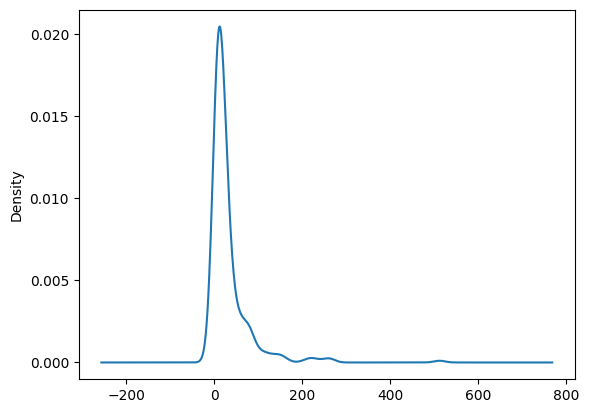

In [272]:
df['Fare'].plot(kind='kde')

<Axes: xlabel='Fare', ylabel='Density'>

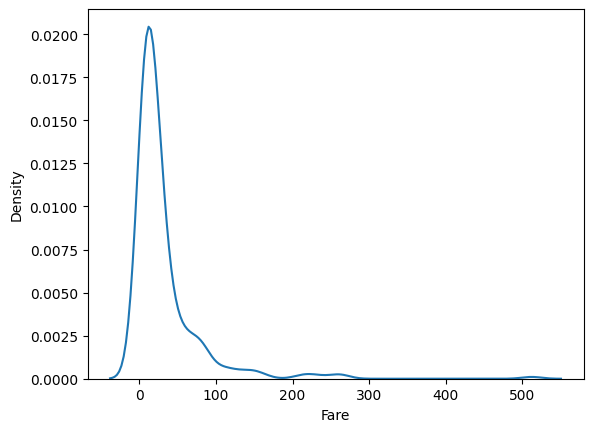

In [273]:
sns.kdeplot(df['Fare'])

In [274]:
df['Fare'].skew()#highly postive skewed

np.float64(4.787316519674893)

In [275]:
fig = px.box(df, y='Fare')
fig.show()

In [276]:
df[df['Fare']>250]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [277]:
df['Fare'].isnull().sum()

np.int64(0)

# univariate analysis on categorical columns

###survived
more than 50 precent couldnt survive accident

In [278]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [279]:
fig = px.bar(df['Survived'].value_counts())
fig.show()

In [280]:
fig = px.pie(df['Survived'].value_counts().reset_index(), names='Survived', values='count', title='Survival Distribution')
fig.show()

In [281]:
df['Survived'].isnull().sum()

np.int64(0)

#suprisingly less people travelled in p class 2 more in p class 1

In [282]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [283]:
fig = px.bar(df['Pclass'].value_counts())
fig.show()

In [284]:
px.pie(df['Pclass'].value_counts().reset_index(), names='Pclass', values='count', title='Pclass passenger distribution')

In [285]:
df['Pclass'].isnull().sum()

np.int64(0)

In [286]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [287]:
df['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [288]:
df['Parch'].value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


# parent child and Sibsp columns can be merged to form a new family size
#create a new column called is alone

#embarked

In [289]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [290]:
fig=px.bar(df['Embarked'].value_counts())
fig.show()

need to feature enginner the mixed column s to get more insights


In [291]:
pd.crosstab(df['Survived'],df['Pclass'])

Pclass,1,2,3
Survived,,,
0,80,97,372
1,136,87,119


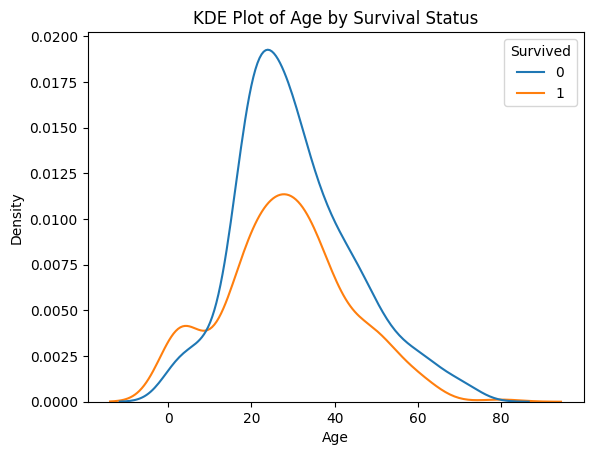

In [292]:
sns.kdeplot(data=df, x='Age', hue='Survived')
plt.title('KDE Plot of Age by Survival Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

The KDE plot shows that survival probability varies with age. Younger adults (20–40) had lower survival compared to children, who show relatively higher survival density. Age appears to be an important feature influencing survival

In [293]:
df[df['Pclass']==1]['Age'].mean()

np.float64(38.233440860215055)

#feature enginnering
#1.)fare column

In [294]:
#how can we create a new column where we get individual fares
df['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [295]:
df[df['SibSp']==8]# sirnaqme first word of name same so thinkimg same family

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [296]:
df[df['Ticket']=='CA. 2343']# shuld be 11 family including him but only 7

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [297]:
df1=pd.read_csv('/content/train.csv')

In [298]:
df=pd.concat([df,df1])

In [299]:
df[df['Ticket']=='CA 2144'].shape

(12, 12)

In [300]:
df[df['Ticket']=='CA 2144']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
59,60,0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.9,NaN,S
71,72,0,3,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,CA 2144,46.9,NaN,S
386,387,0,3,"Goodwin, Master. Sidney Leonard",male,1.0,5,2,CA 2144,46.9,NaN,S
480,481,0,3,"Goodwin, Master. Harold Victor",male,9.0,5,2,CA 2144,46.9,NaN,S
678,679,0,3,"Goodwin, Mrs. Frederick (Augusta Tyler)",female,43.0,1,6,CA 2144,46.9,NaN,S
683,684,0,3,"Goodwin, Mr. Charles Edward",male,14.0,5,2,CA 2144,46.9,NaN,S
59,60,0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.9,NaN,S
71,72,0,3,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,CA 2144,46.9,NaN,S
386,387,0,3,"Goodwin, Master. Sidney Leonard",male,1.0,5,2,CA 2144,46.9,NaN,S
480,481,0,3,"Goodwin, Master. Harold Victor",male,9.0,5,2,CA 2144,46.9,NaN,S


In [301]:
df['FamilySize']=df['SibSp']+df['Parch']+1

In [302]:
df['individual_fare']=df['Fare']/df['FamilySize']

In [303]:
df[['individual_fare','Fare']].describe()

,individual_fare,Fare
count,1782.000000,1782.000000
mean,19.916375,32.204208
std,35.831194,49.679476
min,0.000000,0.000000
25%,7.250000,7.903100
50%,8.300000,14.454200
75%,23.666667,31.000000
max,512.329200,512.329200


# there is someone who paid 512 dollars

<Axes: ylabel='individual_fare'>

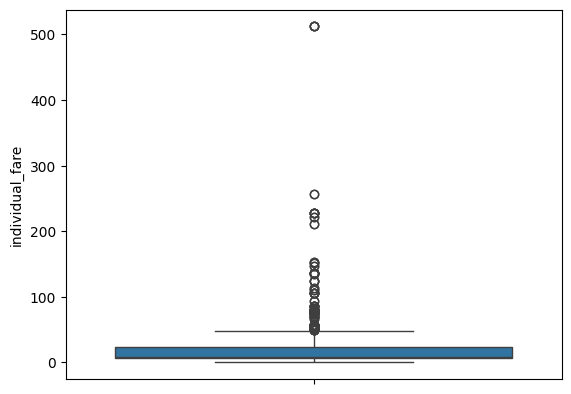

In [304]:
sns.boxplot(df['individual_fare'])

In [305]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,individual_fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,3.62500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,35.64165
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,7.92500
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,26.55000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,8.05000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,13.00000
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,30.00000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,5.86250
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,30.00000


In [306]:
def transform_family_size(num):
  if num==1:
    return 'alone'
  elif num>1 and num<=4:
    return 'small'
  else:
    return 'big'


In [307]:
df['FamilyType']=df['FamilySize'].apply(transform_family_size)

In [308]:
pd.crosstab(df['Survived'],df['FamilyType'],normalize='columns')*100

FamilyType,alone,big,small
Survived,,,
0,69.646182,83.870968,42.123288
1,30.353818,16.129032,57.876712


small family in titanic higher chance to survive

In [309]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,individual_fare,FamilyType
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,3.62500,small
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,35.64165,small
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,7.92500,alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,26.55000,small
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,8.05000,alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,13.00000,alone
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,30.00000,alone
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,5.86250,small
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,30.00000,alone


In [310]:
df['Surname']=df['Name'].str.split(',').str.get(0)

In [311]:
df['Cabin'].isnull().sum()/len(df['Cabin'])

np.float64(0.7710437710437711)

In [312]:
df['Cabin'].fillna('M',inplace=True)

/tmp/ipykernel_9855/3032343573.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [313]:
df['Cabin'].value_counts()

,count
Cabin,
M,1374
G6,8
C23 C25 C27,8
B96 B98,8
F2,6
...,...
E17,2
A24,2
C50,2


In [314]:
df['deck']=df['Cabin'].str[0]

In [315]:
df['deck'].value_counts()

,count
deck,
M,1374
C,118
B,94
D,66
E,64
A,30
F,26
G,8
T,2


In [316]:
pd.crosstab(df['Pclass'],df['deck'])

deck,A,B,C,D,E,F,G,M,T
Pclass,,,,,,,,,
1,30,94,118,58,50,0,0,80,2
2,0,0,0,8,8,16,0,336,0
3,0,0,0,0,6,10,8,958,0


<Axes: xlabel='Survived'>

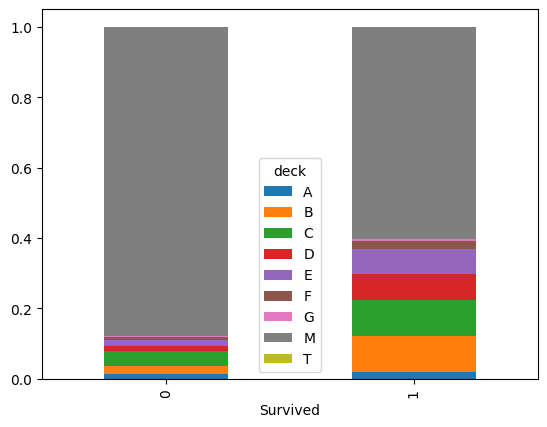

In [317]:
pd.crosstab(df['Survived'],df['deck'],normalize='index').plot(kind='bar',stacked=True)

<Axes: >

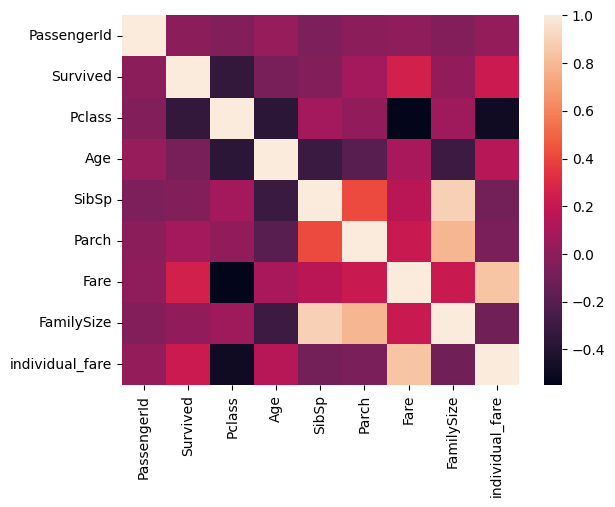

In [318]:
sns.heatmap(df.corr(numeric_only=True))

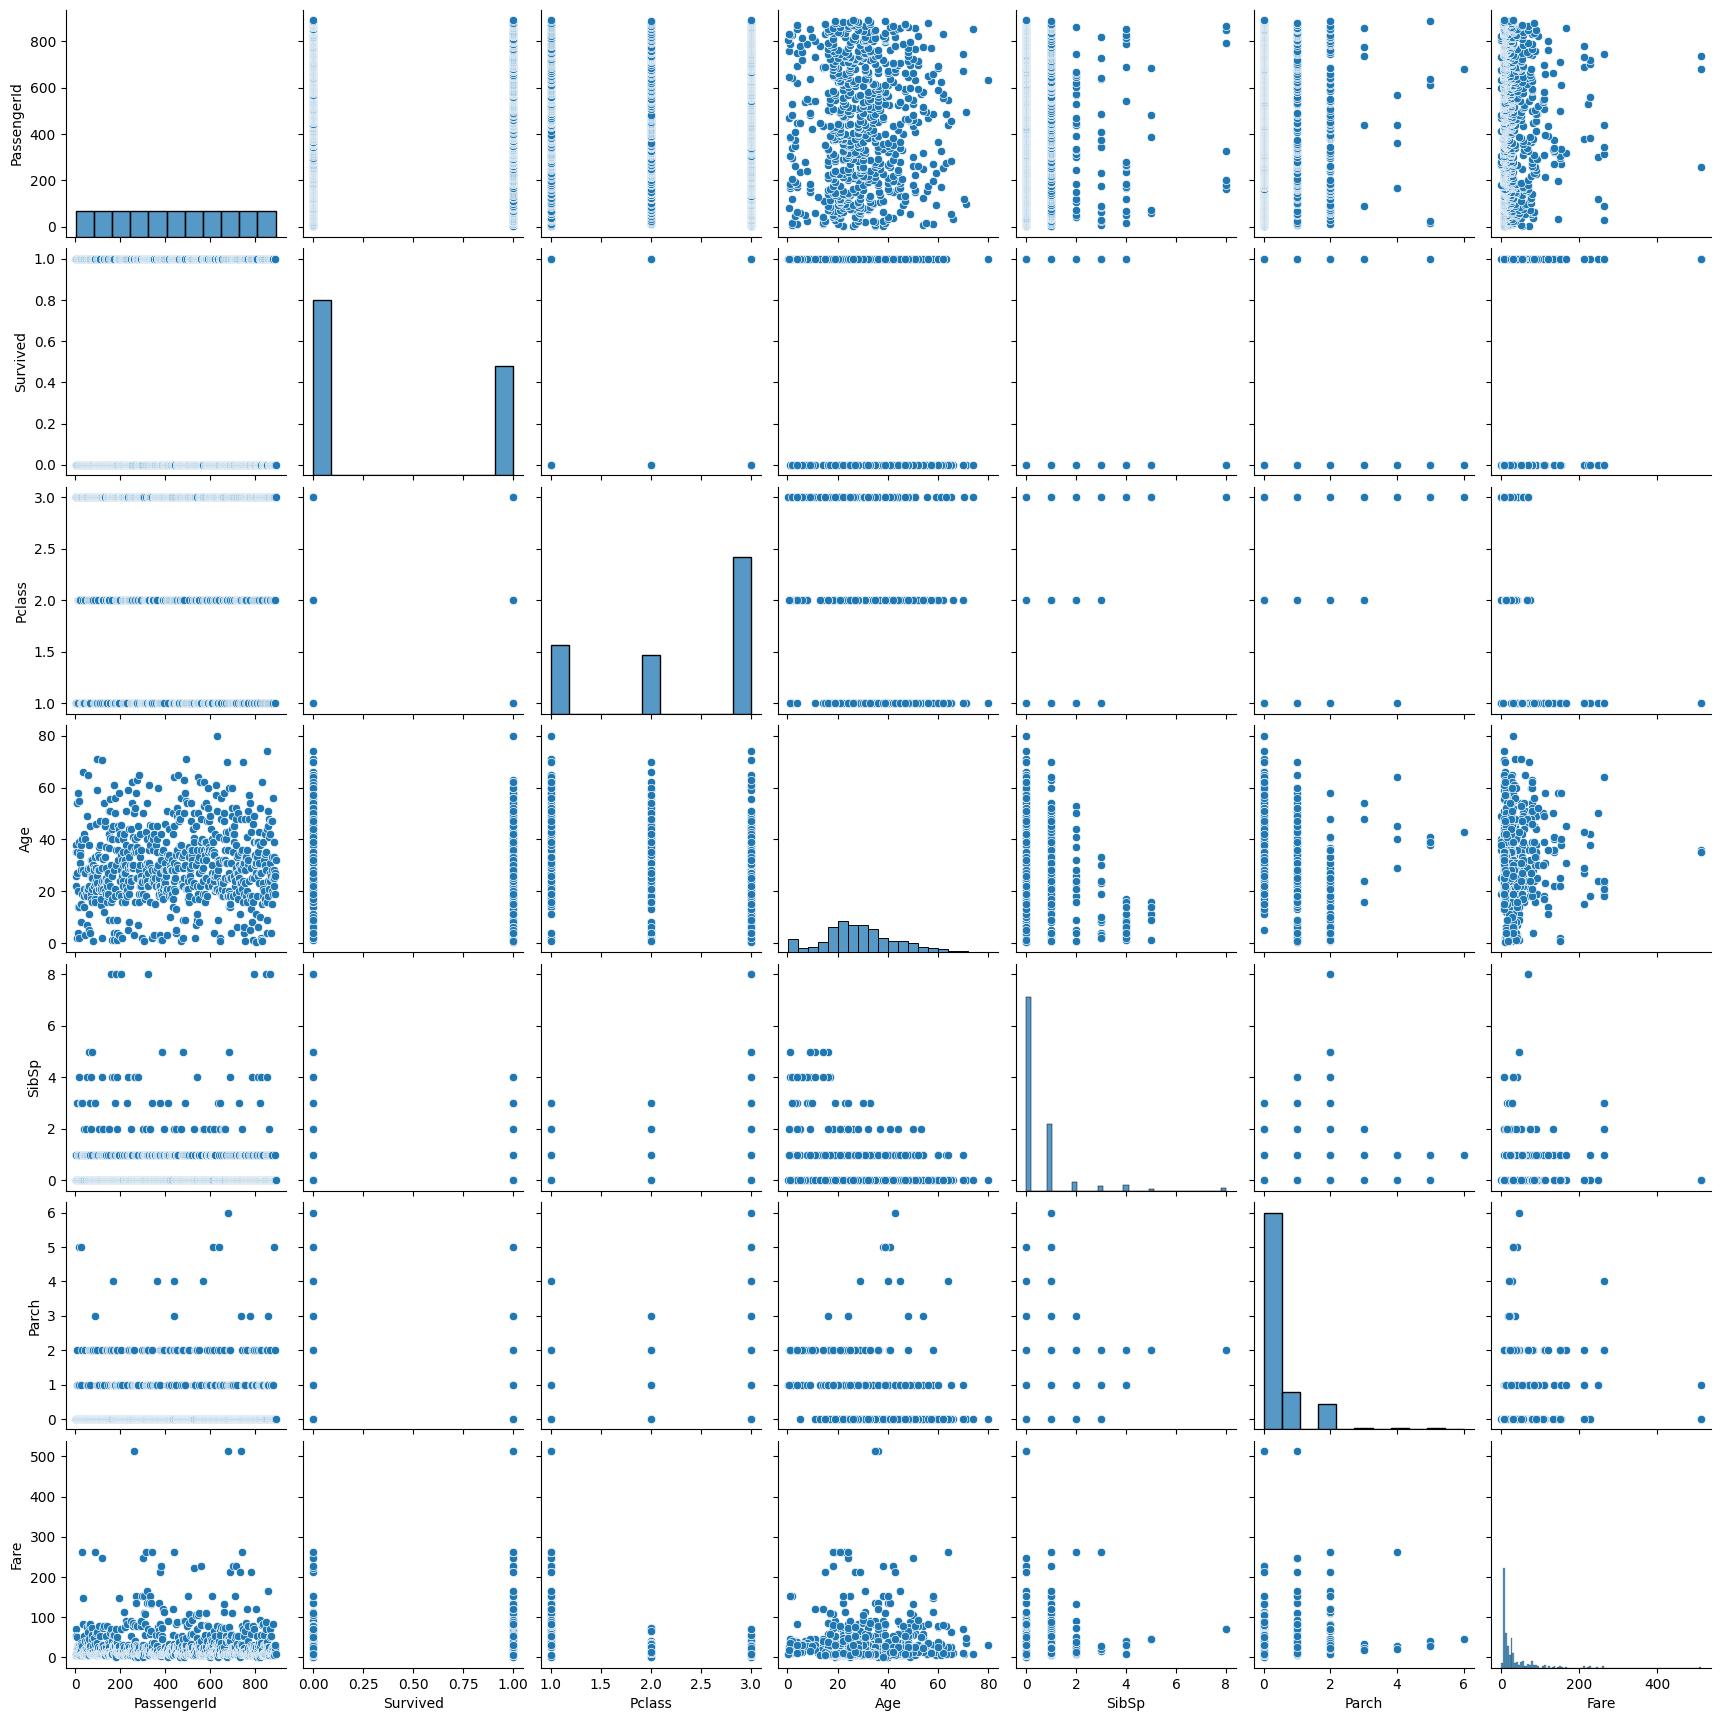

In [319]:
sns.pairplot(df1)